## Build a framework for making neural nets

### Task 1: Make a class for an object that can do implement the basic neuron and calculate gradients
The basic neuron is of the form:

$f\left(\displaystyle\sum_{i}{x_i w_i} + b\right)$

where $f(a)$ is a non-linear function whose output should be constrained between $[-1, 1]$, something like the $\tanh$ function.

In [4]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._children = set(_children)
        self._op = _op
        self.label = label

        self.grad = 0.0
        self._backward = lambda: None
    
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other: Value | int | float):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            return
        out._backward = _backward
        return out
    
    def __sub__(self, other):
        raise NotImplementedError
    
    def __mul__(self, other: Value | int | float):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            return
        out._backward = _backward
        return out

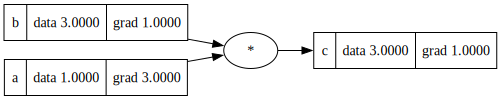

In [ ]:
a = Value(1.0); a.label = 'a'
b = Value(3.0); b.label = 'b'

c = a*b; c.label = 'c'

from drawNodes import draw_dot
draw_dot(c)